In [1]:
# data analysis
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from pyampute.exploration.md_patterns import mdPatterns
from pyampute.exploration.mcar_statistical_tests import MCARTest
import missingno as msno


# preprocessing
import sklearn.utils.validation
import sys
from scipy import stats
from scipy.stats import shapiro, distributions, loguniform
from scipy.stats.mstats import winsorize
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, HalvingRandomSearchCV, HalvingGridSearchCV, TunedThresholdClassifierCV, FixedThresholdClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, QuantileTransformer, MinMaxScaler, KBinsDiscretizer, Binarizer, PolynomialFeatures, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from feature_engine.outliers import Winsorizer
# from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.pipeline import Pipeline
from sklearn import set_config

# Feature Selection
from sklearn.feature_selection import SelectFromModel

# Modeling
from sklearn.linear_model import RidgeClassifier, LogisticRegression, RidgeClassifierCV, LogisticRegressionCV, SGDClassifier, Perceptron, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
import joblib
from sklearn import tree 
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, VotingClassifier, StackingClassifier
from lightgbm import LGBMClassifier 
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid, RadiusNeighborsClassifier

# Metrics
from sklearn.metrics import confusion_matrix, recall_score, precision_score, balanced_accuracy_score, ConfusionMatrixDisplay, classification_report, precision_recall_curve, PrecisionRecallDisplay, log_loss, brier_score_loss, roc_curve, roc_auc_score, RocCurveDisplay, det_curve, DetCurveDisplay, fbeta_score, average_precision_score, matthews_corrcoef

# Calibration
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV

# Inspection
from sklearn.inspection import PartialDependenceDisplay

# Custom Functions
from credit_risk_modeling import model_eval
import importlib
importlib.reload(model_eval)

# Class Imbalance
from imblearn.over_sampling import SMOTE

2026-01-16 08:59:46.433 | INFO     | credit_risk_modeling.config:<module>:11 - PROJ_ROOT path is: C:\Users\billy\OneDrive\Documents\Finance_Projects\credit_risk_modeling


## Imports

In [2]:
X_train = pd.read_csv(
    filepath_or_buffer = "../data/processed/X_train_distance.csv"
)
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22686 entries, 0 to 22685
Data columns (total 25 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   numeric__person_age                          22686 non-null  float64
 1   numeric__person_income                       22686 non-null  float64
 2   numeric__person_emp_length                   22686 non-null  float64
 3   numeric__loan_amnt                           22686 non-null  float64
 4   numeric__loan_int_rate                       22686 non-null  float64
 5   numeric__loan_percent_income                 22686 non-null  float64
 6   numeric__cb_person_cred_hist_length          22686 non-null  float64
 7   categorical__person_home_ownership_MORTGAGE  22686 non-null  float64
 8   categorical__person_home_ownership_OTHER     22686 non-null  float64
 9   categorical__person_home_ownership_OWN       22686 non-null  float64
 10

In [4]:
X_test = pd.read_csv(
    filepath_or_buffer = "../data/processed/X_test_distance.csv"
)
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9723 entries, 0 to 9722
Data columns (total 25 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   numeric__person_age                          9723 non-null   float64
 1   numeric__person_income                       9723 non-null   float64
 2   numeric__person_emp_length                   9723 non-null   float64
 3   numeric__loan_amnt                           9723 non-null   float64
 4   numeric__loan_int_rate                       9723 non-null   float64
 5   numeric__loan_percent_income                 9723 non-null   float64
 6   numeric__cb_person_cred_hist_length          9723 non-null   float64
 7   categorical__person_home_ownership_MORTGAGE  9723 non-null   float64
 8   categorical__person_home_ownership_OTHER     9723 non-null   float64
 9   categorical__person_home_ownership_OWN       9723 non-null   float64
 10  

In [5]:
y_train = pd.read_csv(
    filepath_or_buffer = "../data/interim/y_train.csv"
)
y_train = y_train.values.ravel()

In [6]:
y_test = pd.read_csv(
    filepath_or_buffer = "../data/interim/y_test.csv"
)
y_test.head(1)
y_test = y_test.values.ravel()

## Compare Models

In [7]:
untuned_models = [
    KNeighborsClassifier(
        algorithm='kd_tree',
        n_jobs=-1
    ),
    RadiusNeighborsClassifier(
        radius=5.0,
        algorithm= 'kd_tree',
        n_jobs=-1
    ),
    NearestCentroid(), # contains internal feature selection
    SVC(
        kernel = 'rbf',
        random_state=42
    ),
]

In [8]:
untuned_model_performances, fitted_models = model_eval.comparing_models(untuned_models, X_train, y_train, X_test, y_test)

In [9]:
untuned_model_performances['is_untuned_model'] = 1
untuned_model_performances

,model,roc_auc,pr_auc,log_loss,brier_score,matthews_corrcoef,is_untuned_model
3,SVC (class_weight=None),0.900937,0.840715,NaN,NaN,0.742034,1
0,KNeighborsClassifier (n_jobs=-1),0.866809,0.742806,1.331385,0.090816,0.662036,1
1,RadiusNeighborsClassifier (n_jobs=-1),0.864973,0.700446,0.377223,0.117608,0.442507,1
2,NearestCentroid,0.847113,0.663724,0.863571,0.184248,0.476991,1


Low KNN values due to no class imbalance handling

## Hyperparameter Tuning, Class Imbalance, Feature Selection

### SVC

In [10]:
svc = SVC(
    probability= True,
    class_weight='balanced',
    random_state=42
)

In [11]:
svc_param_dist = {
    'C': stats.loguniform(1e-3, 1e3),
    'gamma': stats.loguniform(1e-4, 1e1),
    'kernel': ['poly', 'rbf', 'sigmoid']
}

In [12]:
svc_tuned = HalvingRandomSearchCV(
    estimator=svc,
    param_distributions=svc_param_dist,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

### KNN

In [13]:
knn= KNeighborsClassifier(
    n_jobs=-1
)

In [14]:
knn_param_dist = {
    'n_neighbors': stats.randint(3, 32),
    'weights': ['uniform', 'distance'],
    'algorithm': ['kd_tree', 'ball_tree'],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

In [15]:
knn_tuned = HalvingRandomSearchCV(
    estimator= knn,
    param_distributions= knn_param_dist,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

### Radius Neighbors Classifier

In [16]:
rnc = RadiusNeighborsClassifier(
    radius=10.0,
    n_jobs=-1
    ),
rnc = rnc[0]

In [17]:
rnc_param_dist = {
    'weights': ['uniform', 'distance'],
    'algorithm': ['kd_tree', 'ball_tree'],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

In [18]:
rnc_tuned = HalvingRandomSearchCV(
    estimator= rnc,
    param_distributions= rnc_param_dist,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [19]:
models = [
    svc_tuned
]

In [20]:
smoted_models = [
    knn_tuned,
    rnc_tuned
]

In [21]:
tuned_model_performance, fitted_models = model_eval.comparing_manually_tuned_models(
    models,
    X_train,
    y_train,
    X_test,
    y_test,
)

c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan ... nan nan nan]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.75277778 0.81166667 0.77222222]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.7837856  0.78521342 0.79179007]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.84339753 0.83676668 0.83704842]
  warnings.warn(
c:\Use

In [22]:
smoted_tuned_performance, fitted_models_smoted = model_eval.comparing_manually_tuned_smoted_models(
    smoted_models,
    X_train,
    y_train,
    X_test,
    y_test,
)

n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 20
max_resources_: 35448
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 1772
n_resources: 20
Fitting 5 folds for each of 1772 candidates, totalling 8860 fits


c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan ... nan nan nan]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the train scores are non-finite: [       nan 0.74203571        nan ... 0.71282143        nan 0.84294643]
  warnings.warn(


----------
iter: 1
n_candidates: 591
n_resources: 60
Fitting 5 folds for each of 591 candidates, totalling 2955 fits


c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.74365079 0.72777778 0.71738095]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the train scores are non-finite: [       nan 0.74203571        nan ... 0.8640817  0.827295   0.88537639]
  warnings.warn(


----------
iter: 2
n_candidates: 197
n_resources: 180
Fitting 5 folds for each of 197 candidates, totalling 985 fits


...

c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.94023667 0.94023667 0.94195374]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the train scores are non-finite: [       nan 0.74203571        nan ... 1.         1.         1.        ]
  warnings.warn(


n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 7
min_resources_: 20
max_resources_: 35448
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 8
n_resources: 20
Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=1772. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan]
  warnings.warn(


----------
iter: 1
n_candidates: 3
n_resources: 60
Fitting 5 folds for each of 3 candidates, totalling 15 fits


c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


In [23]:
tuned_model_performances = pd.concat(
    objs = [tuned_model_performance, smoted_tuned_performance],
    axis=0
)

In [24]:
tuned_model_performances['is_untuned_model'] = 0

In [25]:
model_performances = model_eval.combine_model_performance(
    tuned_model_performances,
    untuned_model_performances
)

In [26]:
model_performances

,model,roc_auc,pr_auc,log_loss,brier_score,matthews_corrcoef,error,is_untuned_model
0,SVC (class_weight=balanced),0.912942,0.844803,0.258958,0.073840,0.657665,NaN,0
3,SVC (class_weight=None),0.900937,0.840715,NaN,NaN,0.742034,NaN,1
0,KNeighborsClassifier (n_jobs=-1),0.892818,0.803468,0.585197,0.114295,0.575526,NaN,0
0,KNeighborsClassifier (n_jobs=-1),0.866809,0.742806,1.331385,0.090816,0.662036,NaN,1
1,RadiusNeighborsClassifier (n_jobs=-1),0.864973,0.700446,0.377223,0.117608,0.442507,NaN,1
2,NearestCentroid,0.847113,0.663724,0.863571,0.184248,0.476991,NaN,1
1,RadiusNeighborsClassifier (n_jobs=-1),NaN,NaN,NaN,NaN,NaN,No neighbors found for test samples array([ 95...,0


## Calibration

Log loss (sigmoid): 0.2598
Brier score (sigmoid): 0.0741
Log loss (isotonic): 0.2566
Brier score (isotonic): 0.0725


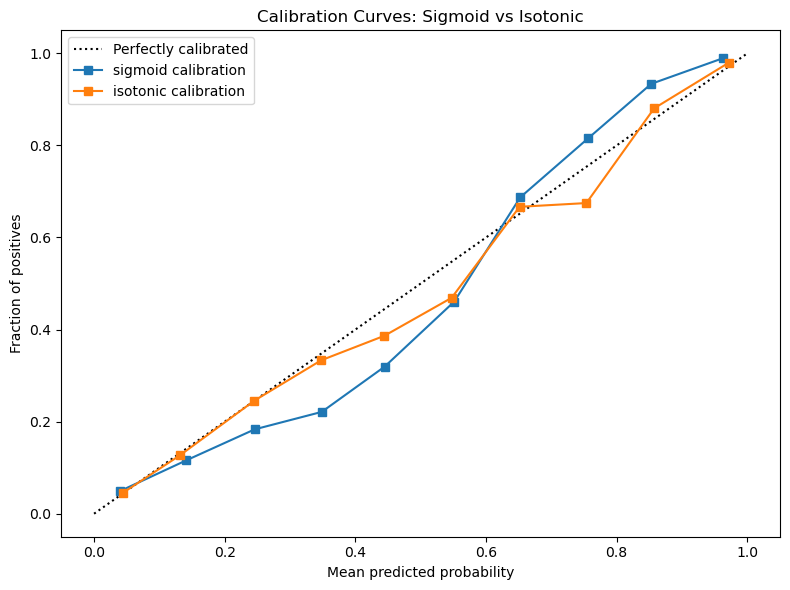

In [27]:
calibrated_models = model_eval.evaluate_calibration(
    model_performances,
    fitted_models,
    X_train,
    y_train,
    X_test, 
    y_test
)

In [28]:
top_performing_calibrated_model= calibrated_models['isotonic']

## Decision Threshold

Classification Report (Base Estimator):
               precision    recall  f1-score   support

       False       0.92      0.97      0.94      7597
        True       0.88      0.68      0.77      2126

    accuracy                           0.91      9723
   macro avg       0.90      0.83      0.86      9723
weighted avg       0.91      0.91      0.91      9723

Business Cost (Base Estimator): $6847500


c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Classification Report (Tuned Estimator):
               precision    recall  f1-score   support

       False       0.00      0.00      0.00      7597
        True       0.22      1.00      0.36      2126

    accuracy                           0.22      9723
   macro avg       0.11      0.50      0.18      9723
weighted avg       0.05      0.22      0.08      9723

Business Cost (Tuned Estimator): $3798500


c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\utils\_plotting.py:440: FutureWarning: y_pred was deprecated in 1.8 and will be removed in 1.10. Please use `y_score` instead.
  warnings.warn(


Classification Report (Chosen Threshold):
               precision    recall  f1-score   support

       False       0.98      0.38      0.54      7597
        True       0.30      0.97      0.46      2126

    accuracy                           0.51      9723
   macro avg       0.64      0.67      0.50      9723
weighted avg       0.83      0.51      0.53      9723

Business Cost (Chosen Threshold): $2970000


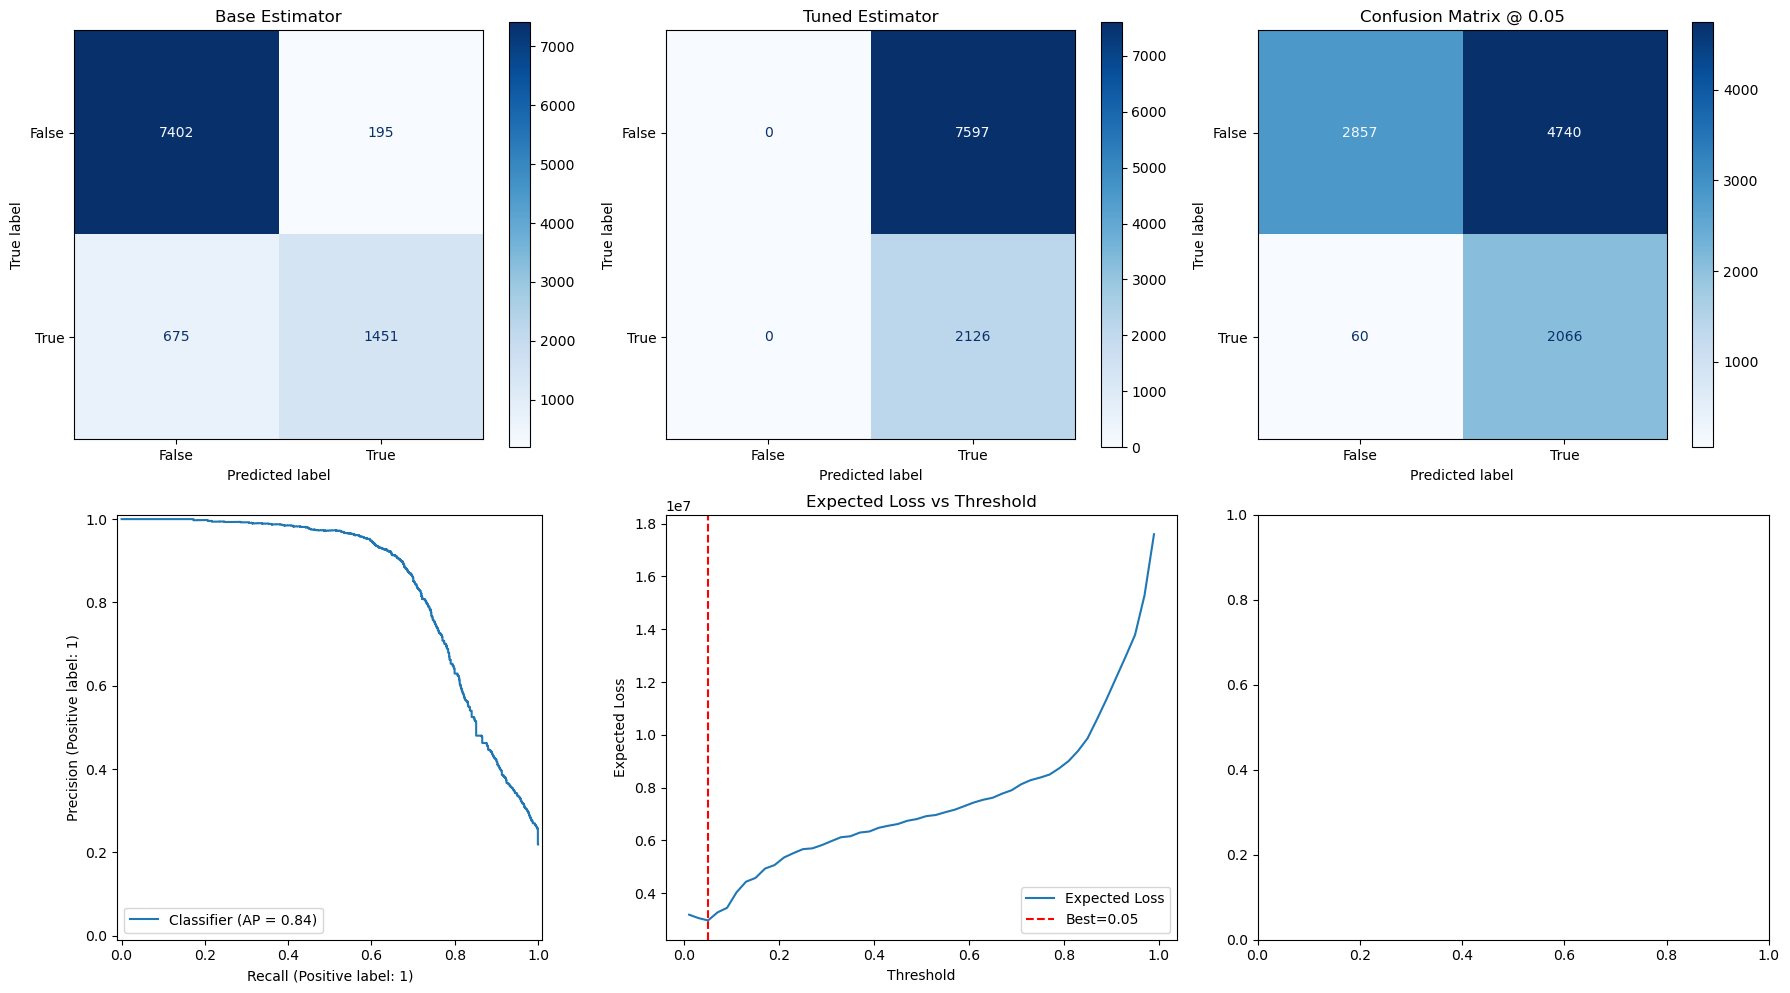

In [29]:
final_model_eval = model_eval.decision_threshold_comparisons(top_performing_calibrated_model, X_train, y_train, X_test, y_test)

In [30]:
final_model_eval

{'base_estimator': CalibratedClassifierCV(estimator=SVC(C=105.91189388091759,
                                      class_weight='balanced',
                                      gamma=0.004578593245736701,
                                      probability=True, random_state=42),
                        method='isotonic', n_jobs=-1),
 'tuned_estimator': TunedThresholdClassifierCV(cv=5,
                            estimator=CalibratedClassifierCV(estimator=SVC(C=105.91189388091759,
                                                                           class_weight='balanced',
                                                                           gamma=0.004578593245736701,
                                                                           probability=True,
                                                                           random_state=42),
                                                             method='isotonic',
                                             

In [31]:
best_distance_model = final_model_eval['chosen_estimator']

In [32]:
joblib.dump(
    value = best_distance_model,
    filename= "../models/best_distance_model.pkl"
)

['../models/best_distance_model.pkl']